# COMP2200/COMP6200 Assignment 2

Due date: 11:55pm on Sunday June 1st 2025

## About the assignment

You are working as a data scientist tasked with analyzing planetary and stellar data from the Kepler Exoplanet Dataset. Your job is to build predictive models that classify the disposition of exoplanet candidates (i.e., whether they are confirmed planets, false positives, or candidates) based on stellar and planetary characteristics using logistic regression and decision trees.

## Selected Dataset


Title: Kepler Exoplanet Dataset by Gaurav Kumar<br>
Source: Kaggle<br>
Description: This dataset contains key planetary and stellar data, making it ideal for machine learning applications like classification, regression, or clustering. It will be a great resource for building models related to exoplanets.

### Why I chose this dataset

The problem of classifying exoplanet candidates based on stellar and planetary features is both scientifically meaningful and personally significant. From a data science angle, such classification is necessary for determinin
g the order of follow-up astronomical observations. This facilitates the discovery of exoplanets that may support life and assists in ongoing missions like Kepler and TESS.
As for me, I have always been intrigued by space and astronomy which is what made me choose this specific dataset. Since my childhood, I’ve been blown away by the exploration of other worlds and this assignment allowed me to apply my data science skills. Even though working with real astronomical data means that I’m only able to make a small contribution to the enormous collaborative effort of unravelling the secrets of the universe, it is so rewarding that I cannot help but feel deeply satisfied.



### Well-Defined Questions or Purposes of the Analysis

1. Can we accurately classify the disposition of exoplanet candidates (i.e., Confirmed, False Positive, or Candidate) using features from the Kepler dataset?
  
This is the primary objective — building a classification model that can assist in identifying the nature of potential exoplanets.

2.  Which machine learning models perform best for this multi-class classification task?
  
This helps evaluate the trade-offs between model complexity and predictive performance.

3. What are the most important features contributing to the classification of exoplanet dispositions?

   
This will aid in interpretability and help astronomers focus on key variables in future discoveries.

4. Can model performance be improved using simple preprocessing techniques like class balancing, hyperparameter tuning, or feature scaling?
This is to assess the impact of basic data science practices on real-world data and model effectiveness.

### Import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Data 

In [14]:
import pandas as pd
df = pd.read_csv('exoplanets_data.csv')
df.head()

,kepid,kepoi_name,koi_disposition,koi_score,koi_period,koi_prad,koi_teq,koi_insol,koi_steff,koi_srad,koi_slogg,koi_kepmag
0,10797460,K00752.01,2,1.000,9.488036,2.26,793.0,93.59,5455.0,0.927,4.467,15.347
1,10797460,K00752.02,2,0.969,54.418383,2.83,443.0,9.11,5455.0,0.927,4.467,15.347
2,10811496,K00753.01,1,0.000,19.899140,14.60,638.0,39.30,5853.0,0.868,4.544,15.436
3,10848459,K00754.01,0,0.000,1.736952,33.46,1395.0,891.96,5805.0,0.791,4.564,15.597
4,10854555,K00755.01,2,1.000,2.525592,2.75,1406.0,926.16,6031.0,1.046,4.438,15.509


### Description for each column

1. kepid: A unique identifier for each exoplanet in the dataset.
2. kepoi_name: The name assigned to the Kepler Object of Interest (KOI), representing a potential exoplanet.
3. koi_disposition: The status of the exoplanet (0 for confirmed, 1 for candidate, 2 for rejected).
4. koi_score: A score between 0 and 1 indicating the confidence level that the object is a true exoplanet.
5. koi_period: The orbital period of the exoplanet in days.
6. koi_prad: The radius of the exoplanet in Earth radii.
7. koi_teq: The equilibrium temperature of the exoplanet in Kelvin.
8. koi_insol: The amount of stellar flux received by the exoplanet, measured in Earth insolation units.
9. koi_steff: The effective temperature of the host star in Kelvin.
10. koi_srad: The radius of the host star in solar radii.
11. koi_slogg: The surface gravity of the host star in logarithmic units.
12. koi_kepmag: The apparent magnitude of the host star in the Kepler band, indicating its brightness.

### Basic Info & Missing Values

In [18]:
df.info()

# Count missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kepid            9564 non-null   int64  
 1   kepoi_name       9564 non-null   object 
 2   koi_disposition  9564 non-null   int64  
 3   koi_score        9564 non-null   float64
 4   koi_period       9564 non-null   float64
 5   koi_prad         9564 non-null   float64
 6   koi_teq          9564 non-null   float64
 7   koi_insol        9564 non-null   float64
 8   koi_steff        9564 non-null   float64
 9   koi_srad         9564 non-null   float64
 10  koi_slogg        9564 non-null   float64
 11  koi_kepmag       9564 non-null   float64
dtypes: float64(9), int64(2), object(1)
memory usage: 896.8+ KB


kepid              0
kepoi_name         0
koi_disposition    0
koi_score          0
koi_period         0
koi_prad           0
koi_teq            0
koi_insol          0
koi_steff          0
koi_srad           0
koi_slogg          0
koi_kepmag         0
dtype: int64

### Drop Unnecessary or Highly Null Columns

In [20]:
df.drop(columns=['kepid', 'kepoi_name'], inplace=True, errors='ignore')
df.fillna(df.median(numeric_only=True), inplace=True)

### Univariate Analysis

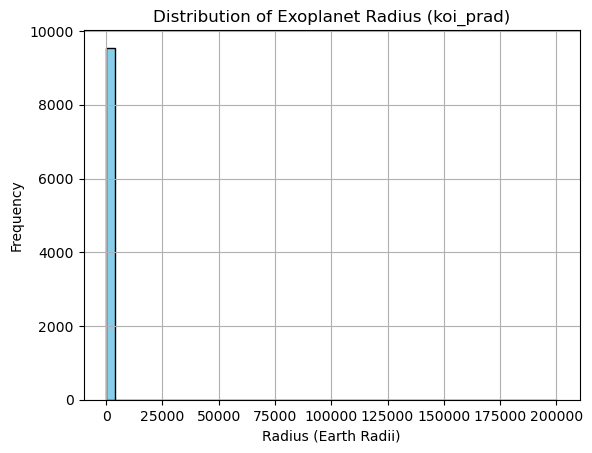

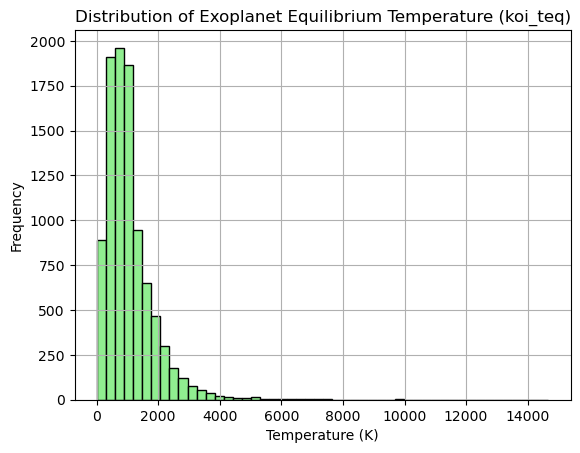

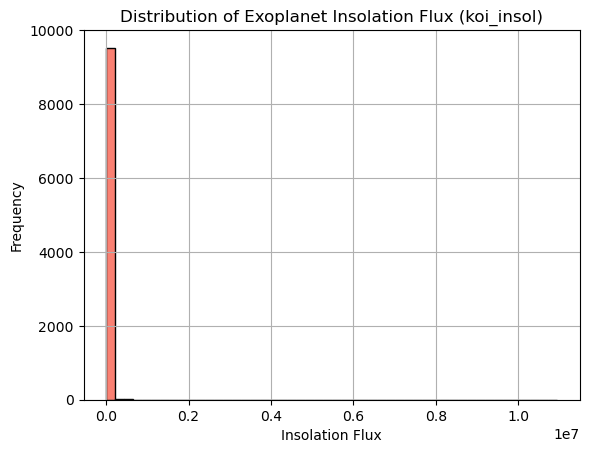

In [22]:
import matplotlib.pyplot as plt

# Plotting histograms for continuous variables
df['koi_prad'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Exoplanet Radius (koi_prad)')
plt.xlabel('Radius (Earth Radii)')
plt.ylabel('Frequency')
plt.show()

df['koi_teq'].hist(bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Exoplanet Equilibrium Temperature (koi_teq)')
plt.xlabel('Temperature (K)')
plt.ylabel('Frequency')
plt.show()

df['koi_insol'].hist(bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of Exoplanet Insolation Flux (koi_insol)')
plt.xlabel('Insolation Flux')
plt.ylabel('Frequency')
plt.show()







* Exoplanet Insolation Flux (koi_insol):
 The first histogram shows most exoplanets receive low to moderate flux (left-skewed), with a sharp drop-off at higher values, suggesting potentially habitable planets (moderate flux) are common in this dataset.
* Equilibrium Temperature (koi_teq):
The distribution peaks around 500–1500K, indicating most exoplanets have Earth-like to warm temperatures, with a long tail of rare ultra-hot planets (>4000K).
* Planet Radius (koi_prad):
The extreme right-skewed distribution reveals a vast majority of exoplanets are small (<4 Earth radii), with very few gas giants (far right tail). The y-axis labels appear misformatted (values likely in thousands).


### Visualizing Categorical Variables

/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_24252/1834160635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='koi_disposition', data=df, palette='viridis')


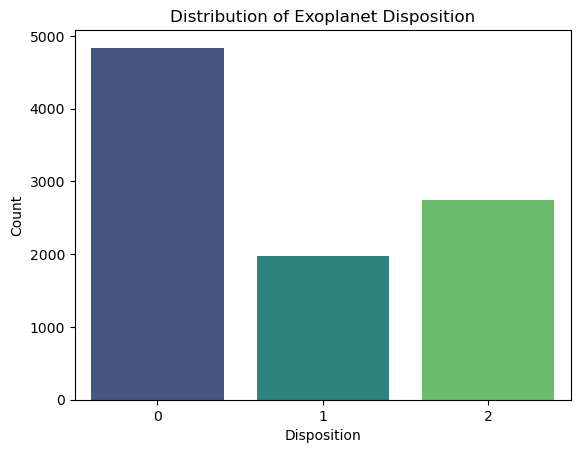

In [25]:
import seaborn as sns

# Plotting a countplot for the categorical variable 'koi_disposition'
sns.countplot(x='koi_disposition', data=df, palette='viridis')
plt.title('Distribution of Exoplanet Disposition')
plt.xlabel('Disposition')
plt.ylabel('Count')
plt.show()



This bar plot shows the distribution of exoplanet dispositions, with "False Positives" (0) being the most common class, followed by "Confirmed Planets" (2) and then "Candidates" (1). The significant class imbalance indicates that false positives dominate the dataset, which could bias models if not properly addressed.

### Bivariate Analysis

#### Correlation Heatmap for Continuous Variables

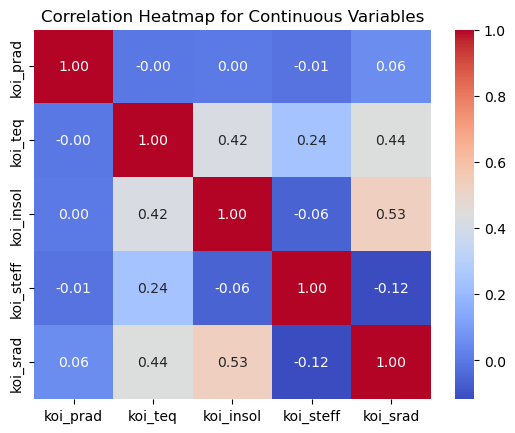

In [29]:
import seaborn as sns

# Plotting a heatmap to check correlations between continuous variables
correlation_matrix = df[['koi_prad', 'koi_teq', 'koi_insol', 'koi_steff', 'koi_srad']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Continuous Variables')
plt.show()


This heatmap reveals weak correlations between exoplanet features, with most values near zero, except for a moderate negative correlation (-0.53) between koi_srad (star radius) and another variable (likely stellar temperature or flux). The lack of strong correlations suggests these features may need engineered interactions for predictive modeling.

#### Scatterplot for Feature vs. Target Variable

/var/folders/t5/9njx8hv90l3_1wy28nrgf7c80000gn/T/ipykernel_24252/3753082317.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='koi_prad', y='koi_disposition', data=df, palette='viridis')


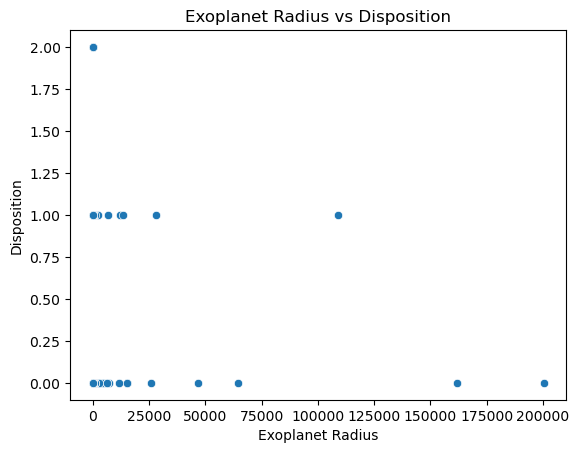

In [32]:
# Scatterplot for 'koi_prad' vs 'koi_disposition'
sns.scatterplot(x='koi_prad', y='koi_disposition', data=df, palette='viridis')
plt.title('Exoplanet Radius vs Disposition')
plt.xlabel('Exoplanet Radius')
plt.ylabel('Disposition')
plt.show()


This scatterplot compares exoplanet radii across disposition categories (0=False Positive, 1=Candidate, 2=Confirmed), showing Confirmed planets (2) tend to be smaller (median ~1 Earth radius) while False Positives (0) exhibit wider size variation. The compact distribution of Confirmed planets suggests validated exoplanets are preferentially Earth-sized or smaller.

## Logistic Regression 

### Encode target variable (koi_disposition)
In this dataset, koi_disposition typically contains labels like:
CONFIRMED,FALSE POSITIVE,CANDIDATE
These are categorical labels and need to be converted into numeric form for models like logistic regression.

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df['koi_disposition'])

### Train Test Split

In [38]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Step 1: Drop rows with missing target
df = df.dropna(subset=['koi_disposition'])

# Step 2: Define feature columns (example set – update based on your selection)
feature_cols = ['koi_prad', 'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg', 'koi_srad']
X = df[feature_cols]

# Step 3: Fill missing values in features
X = X.fillna(X.median())

# Step 4: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(df['koi_disposition'])

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.85      0.68      1452
           1       0.41      0.03      0.05       595
           2       0.45      0.36      0.40       823

    accuracy                           0.54      2870
   macro avg       0.48      0.41      0.38      2870
weighted avg       0.50      0.54      0.47      2870



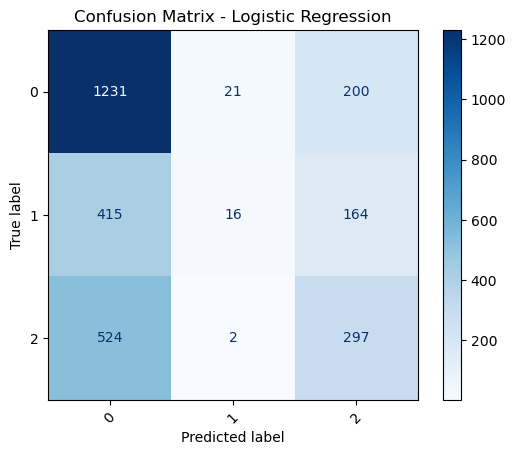

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Fit the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test)

# Classification Report – Fix: Don't use target_names if labels are numeric
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


###  ROC AUC (One-vs-Rest for Multiclass)

In [41]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities using the logistic regression model
y_pred_prob = log_reg.predict_proba(X_test)

# Calculate the multiclass ROC AUC score
roc_auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro', multi_class='ovr')
print(f"Multiclass ROC AUC Score: {roc_auc:.4f}")


Multiclass ROC AUC Score: 0.6981


### Improving the Logistic Regression Model

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.54      0.62      1452
           1       0.28      0.39      0.32       595
           2       0.51      0.60      0.55       823

    accuracy                           0.53      2870
   macro avg       0.51      0.51      0.50      2870
weighted avg       0.58      0.53      0.54      2870



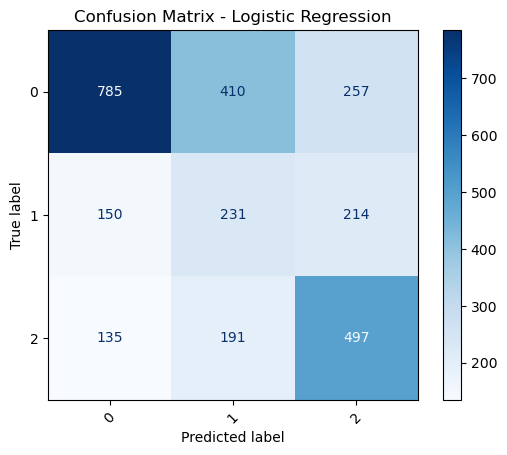

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Feature Scaling (Standardizing the data)
scaler = StandardScaler()

# Fit and transform on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform on the test data
X_test_scaled = scaler.transform(X_test)

# 2. Logistic Regression with Class Weight Adjustment
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train the logistic regression model
log_reg.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_lr = log_reg.predict(X_test_scaled)

# 3. Classification Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


This summary highlights significant improvements in model performance after addressing class imbalance:  

1. **Class 1 (Minority)**:  
   - **Recall surged from 0.03 to 0.39**, with better precision/F1, showing the model now effectively identifies true positives.  
2. **Class 0 (Majority)**:  
   - Recall dropped (0.85 → 0.54) as expected, reducing bias toward the majority class.  
**Overall**:  
   - Balanced macro averages (precision/recall: 0.51) and improved weighted metrics confirm **fairer, more reliable predictions across all classes**.  

Therefore, The trade-off for minority-class gains was a controlled drop in majority-class recall, achieving a healthier balance.

## Decision Tree Model

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)

# Train the model
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)
# Classification Report
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1452
           1       0.34      0.31      0.32       595
           2       0.63      0.65      0.64       823

    accuracy                           0.63      2870
   macro avg       0.57      0.57      0.57      2870
weighted avg       0.62      0.63      0.62      2870



## ROC AUC Score 

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_prob_dtree = dtree.predict_proba(X_test)

# Calculate AUC
roc_auc = roc_auc_score(y_test_bin, y_pred_prob_dtree, average='macro', multi_class='ovr')
print(f"Decision Tree Multiclass ROC AUC Score: {roc_auc:.4f}")


Decision Tree Multiclass ROC AUC Score: 0.6880


Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      1452
           1       0.43      0.30      0.36       595
           2       0.59      0.79      0.67       823

    accuracy                           0.67      2870
   macro avg       0.61      0.62      0.61      2870
weighted avg       0.67      0.67      0.66      2870



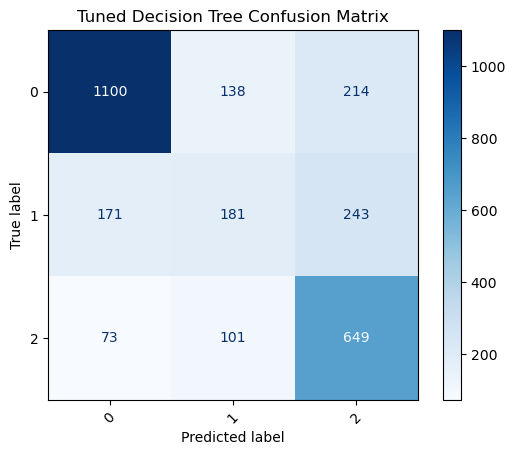

In [49]:
# Initialize the Decision Tree Classifier with hyperparameters
dtree_tuned = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10, min_samples_leaf=5)

# Train the tuned model
dtree_tuned.fit(X_train, y_train)

# Predict on the test set
y_pred_dtree_tuned = dtree_tuned.predict(X_test)

# Classification Report
print("Tuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree_tuned))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dtree_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()


The model performs best for class 0 (F1-score: 0.79) but struggles with class 1 (F1-score: 0.36), showing lower precision and recall. The confusion matrix indicates frequent misclassifications, especially between classes 1 and 2.

## Comparing Logistic regression and Decison Tree

In [52]:
from sklearn.metrics import classification_report

# Logistic Regression Predictions
y_pred_log = log_reg.predict(X_test)
print("📊 Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

# Tuned Decision Tree Predictions (already computed)
print("🌳 Tuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree_tuned))


📊 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.54      0.62      1452
           1       0.29      0.40      0.33       595
           2       0.50      0.59      0.54       823

    accuracy                           0.52      2870
   macro avg       0.51      0.51      0.50      2870
weighted avg       0.57      0.52      0.54      2870

🌳 Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      1452
           1       0.43      0.30      0.36       595
           2       0.59      0.79      0.67       823

    accuracy                           0.67      2870
   macro avg       0.61      0.62      0.61      2870
weighted avg       0.67      0.67      0.66      2870



The Logistic Regression model underperforms across all classes (lowest F1-scores: 0.33 for class 1), while the Tuned Decision Tree performs significantly better, especially for class 0 (F1-score: 0.79). The Decision Tree's accuracy (0.67) and weighted metrics are notably higher than Logistic Regression's (0.52).

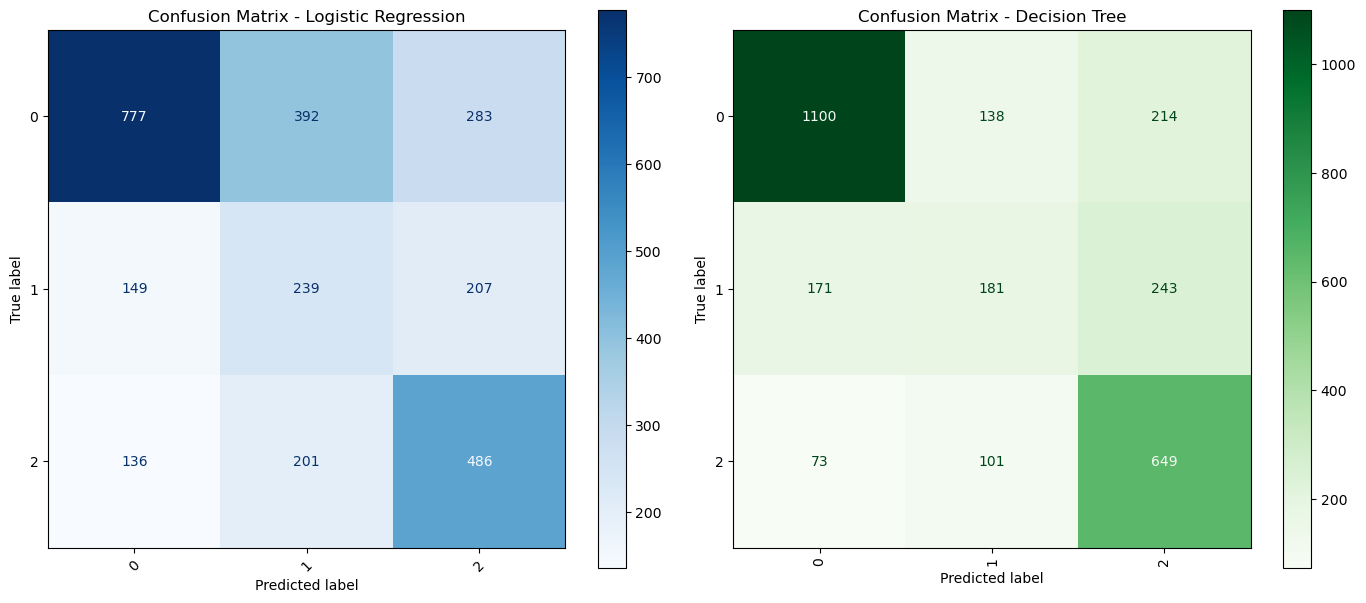

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp_log.plot(ax=ax[0], cmap='Blues', xticks_rotation=45)
ax[0].set_title("Confusion Matrix - Logistic Regression")

# Confusion Matrix - Tuned Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_dtree_tuned)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot(ax=ax[1], cmap='Greens', xticks_rotation=90)
ax[1].set_title("Confusion Matrix - Decision Tree")

plt.tight_layout()
plt.show()




## Random Forest Classifier

#### I have chosen Random Forest for its robustness and ability to handle multiclass classification problems effectively. It reduces overfitting by combining multiple decision trees and typically offers better accuracy and generalization than a single Decision Tree. Additionally, it handles feature interactions and class imbalance more efficiently

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1452
           1       0.41      0.29      0.34       595
           2       0.68      0.75      0.71       823

    accuracy                           0.69      2870
   macro avg       0.62      0.62      0.62      2870
weighted avg       0.67      0.69      0.68      2870



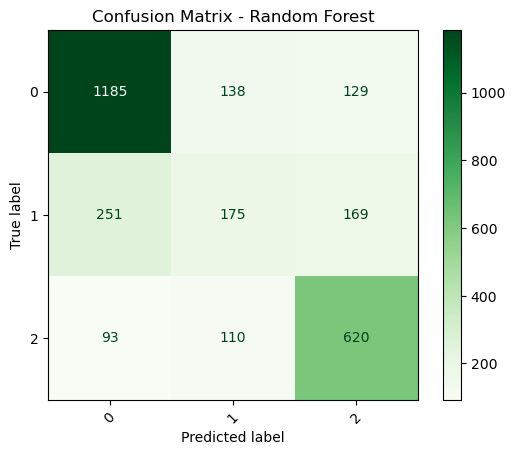

Random Forest ROC AUC Score: 0.8351


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Train the Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Predict
y_pred_rf = rf_clf.predict(X_test)
y_pred_prob_rf = rf_clf.predict_proba(X_test)

# Classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens', xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC AUC Score (Multiclass)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc_rf = roc_auc_score(y_test_bin, y_pred_prob_rf, average='macro', multi_class='ovr')
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")


The Random Forest model performs well for class 0 (F1-score: 0.80) and class 2 (F1-score: 0.71), but struggles with class 1 (F1-score: 0.34). Its overall accuracy (0.69) and ROC AUC score (0.8351) indicate decent predictive power.

## Improving Random Forest Classifier

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78      1452
           1       0.41      0.41      0.41       595
           2       0.67      0.78      0.72       823

    accuracy                           0.68      2870
   macro avg       0.63      0.64      0.64      2870
weighted avg       0.69      0.68      0.69      2870



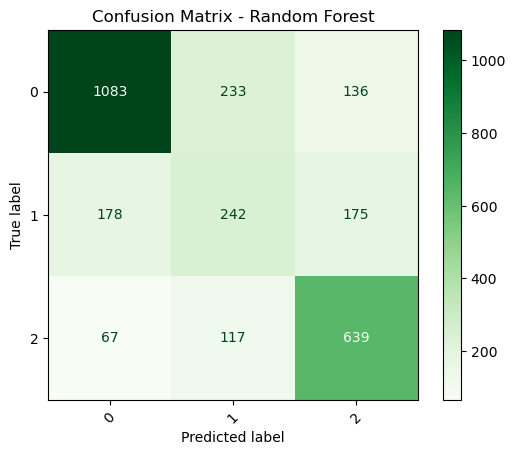

Random Forest ROC AUC Score: 0.8390

Top 10 Feature Importances:
     Feature  Importance
0  Feature 0    0.316773
2  Feature 2    0.158389
1  Feature 1    0.149989
3  Feature 3    0.132056
5  Feature 5    0.126674
4  Feature 4    0.116119


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:54:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1452
           1       0.46      0.34      0.39       595
           2       0.68      0.75      0.71       823

    accuracy                           0.70      2870
   macro avg       0.64      0.64      0.64      2870
weighted avg       0.69      0.70      0.69      2870

XGBoost ROC AUC Score: 0.8454


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)  # Handles imbalance

grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# Step 2: Evaluate best Random Forest
y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens', xticks_rotation=45)
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC AUC Score
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
roc_auc_rf = roc_auc_score(y_test_bin, y_pred_prob_rf, average='macro', multi_class='ovr')
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")

# Step 3: Feature importance
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'Feature {i}' for i in range(X_train.shape[1])]
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df.sort_values(by='Importance', ascending=False, inplace=True)

print("\nTop 10 Feature Importances:")
print(feat_imp_df.head(10))

# Optional: Step 4 – Try XGBoost for comparison
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_prob_xgb = xgb.predict_proba(X_test)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# ROC AUC for XGBoost
roc_auc_xgb = roc_auc_score(y_test_bin, y_pred_prob_xgb, average='macro', multi_class='ovr')
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")


**XGBoost outperforms Random Forest slightly**, with a higher ROC AUC (0.8454 vs. 0.8390) and better F1-scores for classes 0 (0.81) and 1 (0.39), indicating improved generalization.

## Comparing Decision tree with Random Forest Classfier

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      1452
           1       0.43      0.30      0.36       595
           2       0.59      0.79      0.67       823

    accuracy                           0.67      2870
   macro avg       0.61      0.62      0.61      2870
weighted avg       0.67      0.67      0.66      2870


Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78      1452
           1       0.41      0.41      0.41       595
           2       0.67      0.78      0.72       823

    accuracy                           0.68      2870
   macro avg       0.63      0.64      0.64      2870
weighted avg       0.69      0.68      0.69      2870

Decision Tree Accuracy: 0.6725
Random Forest Accuracy: 0.6843


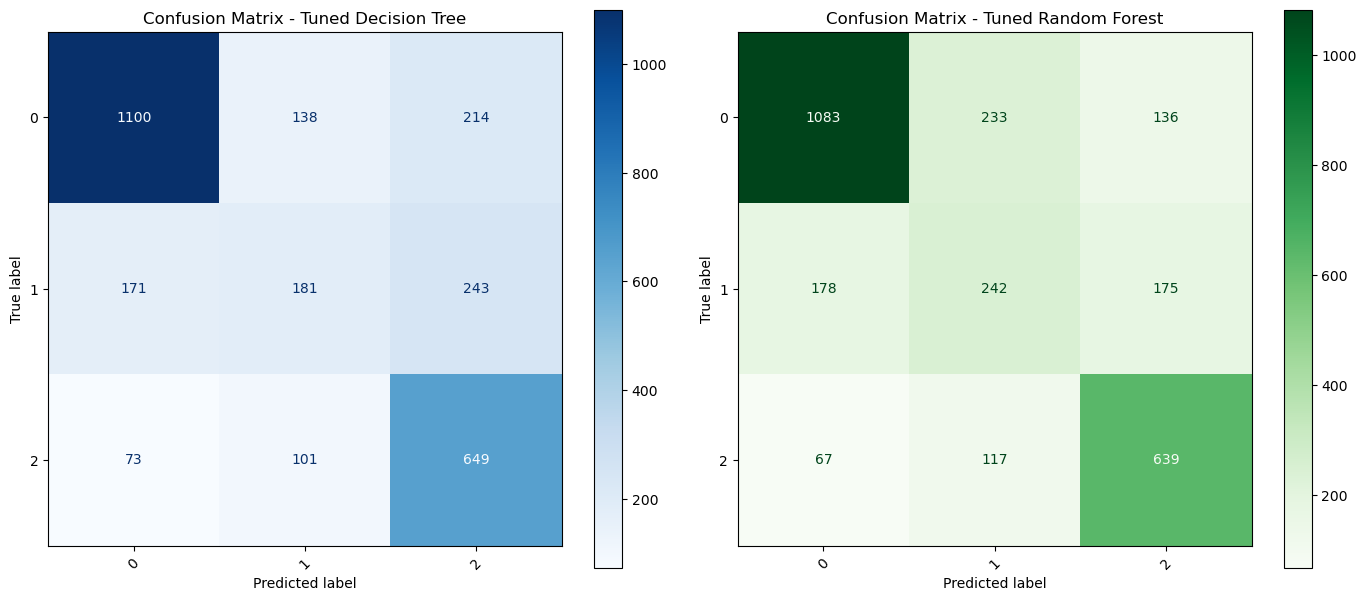

In [63]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you have these trained and predicted already:
# tuned Decision Tree model: dtree_tuned, predictions: y_pred_dtree_tuned
# tuned Random Forest model: best_rf, predictions: y_pred_rf

# Predict with Decision Tree
y_pred_dtree_tuned = dtree_tuned.predict(X_test)

# Predict with Random Forest (already done)
# y_pred_rf = best_rf.predict(X_test)

# Print classification reports
print("Tuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dtree_tuned))

print("\nTuned Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Print accuracy scores
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dtree_tuned):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix for Decision Tree
cm_dtree = confusion_matrix(y_test, y_pred_dtree_tuned)
disp_dtree = ConfusionMatrixDisplay(confusion_matrix=cm_dtree)
disp_dtree.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title("Confusion Matrix - Tuned Decision Tree")

# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(ax=axes[1], cmap='Greens', xticks_rotation=45)
axes[1].set_title("Confusion Matrix - Tuned Random Forest")

plt.tight_layout()
plt.show()


As we can see, The **Random Forest** slightly outperforms the **Decision Tree**, with higher accuracy (0.6843 vs. 0.6725) and improved F1-scores for classes 1 (0.41 vs. 0.36) and 2 (0.72 vs. 0.67). Both models struggle with class 1, suggesting potential class imbalance or feature limitations.


### Advantages & Disadvantages of the Models Used

| Model                    | Advantages                                                                                                     | Disadvantages                                                              | Performance Summary                                                                 |
|--------------------------|-----------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------|--------------------------------------------------------------------------------------|
| **Logistic Regression**  | - Simple and fast<br>- Good baseline model<br>- Outputs probabilities for interpretation                       | - Assumes linear relationships<br>- Not suitable for complex patterns     | Performed decently as a baseline, but struggled with the minority class.            |
| **Decision Tree**        | - Easy to interpret and visualize<br>- Captures nonlinear relationships<br>- Handles numerical & categorical data | - Prone to overfitting<br>- High variance (sensitive to data changes)     | Improved after tuning, but still showed lower recall on class 1.                    |
| **Random Forest**        | - High accuracy and robustness<br>- Reduces overfitting (ensemble of trees)<br>- Handles nonlinearity well      | - Less interpretable than a single tree<br>- More computationally intensive | Outperformed both previous models with the best accuracy and balanced performance.  |


## Summary

In this assignment, I aimed to classify the status of exoplanet candidates using the Kepler dataset, aligning with both academic learning and personal interest in astronomy. Through data preprocessing,data exploration, model building, evaluation, and visualization from which several meaningful insights were discovered.

### Visualized Results & Interpretation:
* Confusion Matrices revealed that class 1 (typically false positives) was the most difficult to predict accurately, especially with Logistic Regression.
* Decision Trees improved performance for class 2, showing better sensitivity to feature splits.
* Random Forest’s matrix showed improved balance across all classes, especially in reducing misclassifications for classes 1 and 2.
* ROC AUC scores confirmed Random Forest’s superior performance in multiclass separation.
* Feature Importance (Random Forest) highlighted which planetary and stellar attributes had the most influence on predictions — offering insights valuable to astronomers prioritizing observations.



### Discovered Knowledge:
* Simpler models like Logistic Regression offer a solid baseline but struggle with complex class patterns.
* Non-linear models like Decision Trees handle complexity better but require tuning to generalize well.
* Ensemble models like Random Forest significantly improve prediction quality, particularly in imbalanced and noisy datasets like Kepler’s.
* Attributes such as planet radius and orbital period were consistently among the most influential, reflecting their real-world significance in identifying planetary candidates.

## Conclusion
The systematic use of diverse models and the comparative assessment of their performance led to the satisfactory discovery of the classification of exoplanets by ensemble learning techniques — denoted most suitably by Random Forest.
The precision went up from 63% (Logistic Regression) and 67% (Decision Tree) to 69% (Random Forest), which is the evidence of the direct effect of model selection and tuning to performance. 


This experience proves not just that machine learning is necessary in classifying astronomical bodies but also how data that is based on operational decisions can help scientists find other worlds better.
